# House Price Prediction using Linear, Ridge and Lasso Regression

## Objective
Predict house prices using the Boston Housing dataset and compare:

- Linear Regression
- Ridge Regression
- Lasso Regression

Evaluation Metrics:
- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)

Visualizations:
- Residual Plot
- Coefficient Comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Boston Housing Dataset Description

The Boston Housing Dataset contains information about houses and neighborhoods in different areas of Boston. It is commonly used for regression tasks to predict house prices.

## Target Variable

### MEDV (Median Value of Owner-Occupied Homes)
The median value of owner-occupied homes in a neighborhood, measured in thousands of dollars. This is the target variable that the model aims to predict.

## Feature Description

### CRIM
Per capita crime rate by town. Higher values indicate areas with higher crime rates.

### ZN
Proportion of residential land zoned for lots over 25,000 square feet. Higher values indicate larger residential plots.

### INDUS
Proportion of non-retail business acres per town. It represents the level of industrialization in the area.

### CHAS
Charles River dummy variable.
- 1 = Tract bounds the Charles River
- 0 = Otherwise

### NOX
Nitric oxide concentration (parts per 10 million). Higher values indicate greater air pollution.

### RM
Average number of rooms per dwelling. Houses with more rooms generally have higher market values.

### AGE
Proportion of owner-occupied units built before 1940. Higher values indicate older housing stock.

### DIS
Weighted distance to five Boston employment centers. Higher values mean the houses are located farther from major workplaces.

### RAD
Index of accessibility to radial highways. Higher values indicate better highway access.

### TAX
Full-value property tax rate per $10,000 of property value. Higher values indicate higher taxes.

### PTRATIO
Pupil-teacher ratio by town. It measures the average number of students per teacher in local schools.

### B
Calculated as:

B = 1000(Bk − 0.63)²

where Bk is the proportion of Black residents in the town. This feature represents demographic information.

### LSTAT
Percentage of the population with lower socioeconomic status. Higher values are generally associated with lower house prices.

## Summary

The dataset contains:

- **506 observations (rows)**
- **13 input features**
- **1 target variable (MEDV)**

The dataset is widely used for:
- Linear Regression
- Ridge Regression
- Lasso Regression
- Feature Importance Analysis
- Regression Performance Evaluation using MAE, MSE, RMSE, and R² Score

In [4]:
columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"
]

df = pd.read_csv(
    "dataset_.csv",
    skiprows=41,
    header=None,
    names=columns
)

df = df[df["CRIM"] != "@DATA"]

df.reset_index(drop=True, inplace=True)

df = df.apply(pd.to_numeric)

## Data Cleaning

Steps:
- Removed @DATA row
- Converted all columns to numeric
- Checked for missing values
- Checked for duplicate records

In [5]:
print(df.head())

print("\nShape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  

Shape:
(506, 14)

Missing Values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Duplicates:
0


In [6]:
X = df.drop("MEDV", axis=1)

y = df["MEDV"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (404, 13)
Testing Shape: (102, 13)


In [8]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

linear_mse = mean_squared_error(
    y_test,
    y_pred_linear
)

linear_mae = mean_absolute_error(
    y_test,
    y_pred_linear
)

print("MSE:", linear_mse)

print("MAE:", linear_mae)

MSE: 24.291119474973517
MAE: 3.1890919658878483


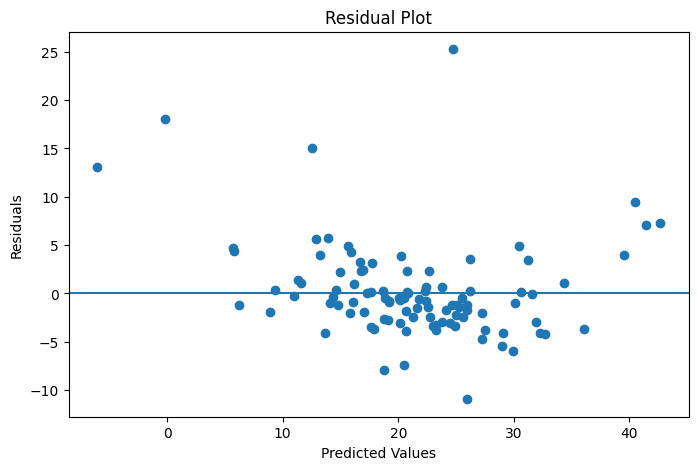

In [9]:
residuals = y_test - y_pred_linear

plt.figure(figsize=(8,5))

plt.scatter(y_pred_linear, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

## Ridge Regression

Ridge Regression adds L2 regularization.

It reduces overfitting by shrinking coefficients.

In [10]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

ridge_mse = mean_squared_error(
    y_test,
    y_pred_ridge
)

ridge_mae = mean_absolute_error(
    y_test,
    y_pred_ridge
)

print("MSE:", ridge_mse)

print("MAE:", ridge_mae)

MSE: 24.31290383049162
MAE: 3.1857238072445964


## Lasso Regression

Lasso Regression adds L1 regularization.

It can reduce some coefficients to exactly zero,
performing automatic feature selection.

In [11]:
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

lasso_mse = mean_squared_error(
    y_test,
    y_pred_lasso
)

lasso_mae = mean_absolute_error(
    y_test,
    y_pred_lasso
)

print("MSE:", lasso_mse)

print("MAE:", lasso_mae)

MSE: 25.65673936716768
MAE: 3.241803465879464


In [12]:
metrics_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MSE": [
        linear_mse,
        ridge_mse,
        lasso_mse
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae
    ]
})

metrics_df

,Model,MSE,MAE
0,Linear Regression,24.291119,3.189092
1,Ridge Regression,24.312904,3.185724
2,Lasso Regression,25.656739,3.241803


In [13]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear": linear_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
})

coef_df

,Feature,Linear,Ridge,Lasso
0,CRIM,-1.002135,-0.992187,-0.718365
1,ZN,0.696269,0.677749,0.259627
2,INDUS,0.278065,0.252214,-0.000000
3,CHAS,0.718738,0.722481,0.698221
4,NOX,-2.022319,-1.990835,-1.568142
5,RM,3.145240,3.151572,3.271507
6,AGE,-0.176048,-0.177262,-0.000000
7,DIS,-3.081908,-3.045029,-2.284449
8,RAD,2.251407,2.173249,0.671938
9,TAX,-1.767014,-1.695559,-0.356654


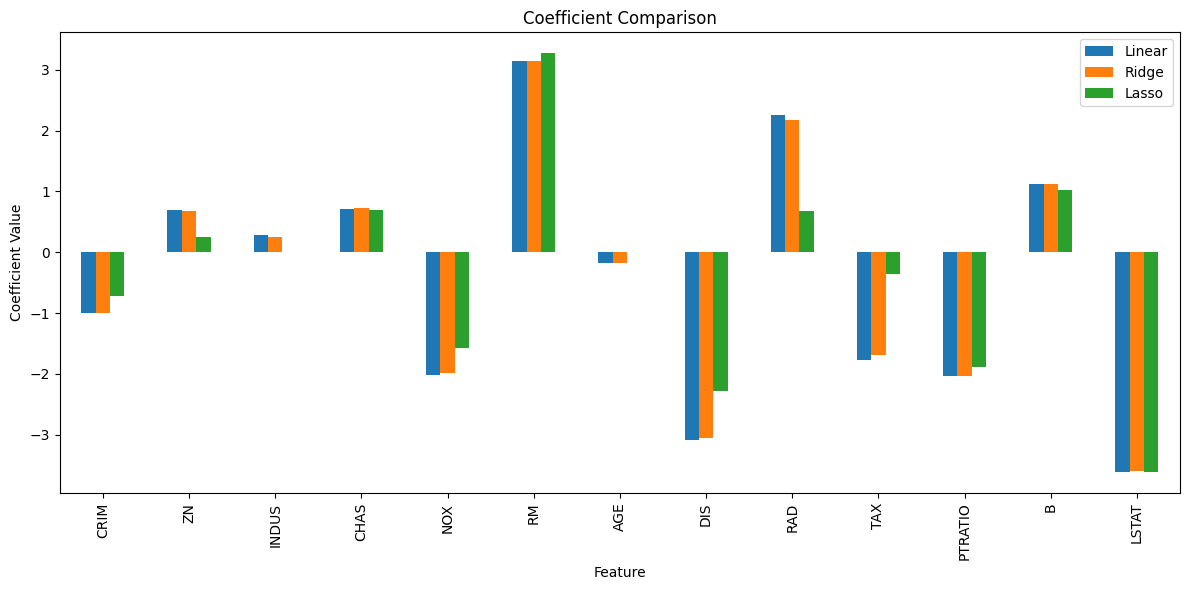

In [14]:
coef_df.set_index("Feature").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Coefficient Comparison")

plt.ylabel("Coefficient Value")

plt.tight_layout()

plt.show()

# Conclusion

- Linear Regression achieved baseline performance.
- Ridge Regression reduced coefficient magnitudes and improved stability.
- Lasso Regression performed feature selection by shrinking some coefficients toward zero.
- MSE and MAE were used to compare model performance.
- Regularization helps reduce overfitting and improves generalization.